# Data Analytics III — Naïve Bayes Classification on Iris Dataset

**Objective:**
1. Implement the Naïve Bayes classification algorithm on the Iris dataset.
2. Compute the Confusion Matrix and derive: TP, FP, TN, FN, Accuracy, Error Rate, Precision, Recall.

**Dataset:** Iris (`iris.csv`) — 150 flowers, 4 numeric features (sepal length/width, petal length/width), 3 species classes.

### Naïve Bayes (quick concept)
Naïve Bayes is a probabilistic classifier based on **Bayes' Theorem**:

$$P(class \mid features) = \frac{P(features \mid class) \cdot P(class)}{P(features)}$$

For each test sample, it computes the probability of each class given the features and picks the highest. It is called *"naïve"* because it assumes all features are **independent** of each other given the class — an assumption that is rarely true in practice but works surprisingly well anyway.

We use **GaussianNB** (Gaussian Naïve Bayes) because our features are continuous numeric values, assumed to follow a normal distribution within each class.

### Difference from previous notebook
Logistic Regression handled **binary** classification (Purchased: 0 or 1). Naïve Bayes here handles **multi-class** classification (3 species). The confusion matrix becomes a 3×3 grid, and we use macro/weighted averages for precision and recall.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — plotting
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split — splits data into training and testing sets
from sklearn.model_selection import train_test_split

# GaussianNB — Naive Bayes for continuous (Gaussian) features
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, classification_report)

%matplotlib inline

## Step 2: Load the Dataset

In [2]:
# Load the Iris dataset from CSV
df = pd.read_csv('Naive_Bayes_Iris_VI.csv')

print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Inspect column types and confirm no missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Class balance — Iris has 50 flowers of each species (perfectly balanced)
print("Class distribution:")
print(df['species'].value_counts())

Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
# Summary statistics of the four numeric features

df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Step 3: Select Features and Target

In [6]:
# X = the 4 numeric features (everything except 'species')
X = df.drop('species', axis=1)

# y = species (the categorical class label we want to predict)
y = df['species']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes to predict:", y.unique())

X shape: (150, 4)
y shape: (150,)
Classes to predict: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


## Step 4: Split into Training and Testing Sets

In [7]:
# 80% training, 20% testing
# random_state=42 makes the split reproducible
# stratify=y keeps the class balance the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nClass balance in training set:")
print(y_train.value_counts())

Training set: (120, 4)
Testing set: (30, 4)

Class balance in training set:
species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64


## Step 5: Train the Naïve Bayes Model

**Note on scaling:** Unlike logistic regression, Naïve Bayes does NOT require feature scaling. It treats each feature independently and computes its mean and standard deviation per class — the absolute scale of each feature doesn't matter.

In [8]:
# Create the classifier
classifier = GaussianNB()

# fit() learns the mean and standard deviation of each feature for each class
# These are then used in Bayes' theorem to compute class probabilities at prediction time
classifier.fit(X_train, y_train)

print("Model trained successfully.")
print("Classes learned:", classifier.classes_)

Model trained successfully.
Classes learned: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Step 6: Make Predictions on the Test Set

In [9]:
# predict() returns the predicted class for each test sample
y_pred = classifier.predict(X_test)

# Compare predictions vs actual values for the first 15 test flowers
comparison = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15]
})
comparison

,Actual,Predicted
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


In [10]:
# predict_proba() returns the probability of each class for each sample
# Useful to see how confident the model is in each prediction
probabilities = classifier.predict_proba(X_test[:5])
proba_df = pd.DataFrame(probabilities, columns=classifier.classes_)
print("Class probabilities for the first 5 test samples:")
proba_df.round(4)

Class probabilities for the first 5 test samples:


,Iris-setosa,Iris-versicolor,Iris-virginica
0,1.0,0.0000,0.0000
1,0.0,0.0877,0.9123
2,0.0,1.0000,0.0000
3,0.0,1.0000,0.0000
4,1.0,0.0000,0.0000


## Step 7: Confusion Matrix (3×3 for Multi-Class)

For 3 classes, the confusion matrix is 3×3. The rows are the actual classes, the columns are the predicted classes. The diagonal cells are correct predictions; everything off-diagonal is an error.

|                       | Pred: setosa | Pred: versicolor | Pred: virginica |
|-----------------------|--------------|------------------|-----------------|
| **Actual: setosa**    | correct      | error            | error           |
| **Actual: versicolor**| error        | correct          | error           |
| **Actual: virginica** | error        | error            | correct         |

In [11]:
# confusion_matrix(actual, predicted) returns a 3x3 array for 3 classes
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)

print("Confusion Matrix:")
print(cm)
print("\nRows = actual class, Columns = predicted class")
print("Class order:", classifier.classes_)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Rows = actual class, Columns = predicted class
Class order: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


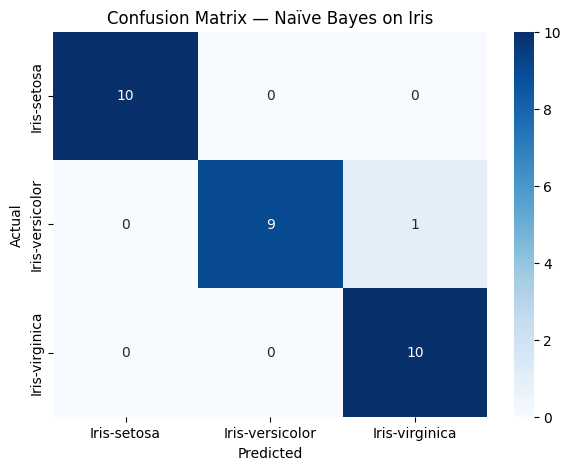

In [12]:
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classifier.classes_,
            yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naïve Bayes on Iris')
plt.show()

### Compute TP, FP, FN, TN per class

In multi-class classification, TP/FP/FN/TN are defined **per class** using a one-vs-rest view:
- **TP (True Positive)** for class C — correctly predicted as C
- **FP (False Positive)** for class C — predicted as C but actually another class
- **FN (False Negative)** for class C — actually C but predicted as another class
- **TN (True Negative)** for class C — neither actual nor predicted is C

In [13]:
# Compute TP, FP, FN, TN for each of the 3 classes
classes = classifier.classes_
total = cm.sum()

print(f"{'Class':<20} {'TP':>5} {'FP':>5} {'FN':>5} {'TN':>5}")
print("-" * 45)

per_class_stats = {}
for i, cls in enumerate(classes):
    TP = cm[i, i]                         # diagonal cell for this class
    FP = cm[:, i].sum() - TP              # column sum minus diagonal
    FN = cm[i, :].sum() - TP              # row sum minus diagonal
    TN = total - TP - FP - FN             # everything else
    per_class_stats[cls] = {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN}
    print(f"{cls:<20} {TP:>5} {FP:>5} {FN:>5} {TN:>5}")

Class                   TP    FP    FN    TN
---------------------------------------------
Iris-setosa             10     0     0    20
Iris-versicolor          9     0     1    20
Iris-virginica          10     1     0    19


## Step 8: Compute Performance Metrics

**Accuracy** = (sum of diagonal) / total = correct predictions / total predictions

**Error Rate** = 1 − Accuracy

**Precision (per class)** = TP / (TP + FP)
> Of all the times the model predicted this class, how many were correct?

**Recall (per class)** = TP / (TP + FN)
> Of all actual cases of this class, how many did the model catch?

For multi-class problems we report **macro average** (unweighted mean across classes — treats all classes equally) and **weighted average** (weighted by class size).

In [14]:
# Overall accuracy and error rate
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print(f"Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Error Rate : {error_rate:.4f}  ({error_rate*100:.2f}%)")

Accuracy   : 0.9667  (96.67%)
Error Rate : 0.0333  (3.33%)


In [15]:
# Per-class precision and recall — one number per class
print("Per-class precision and recall:\n")
print(f"{'Class':<20} {'Precision':>10} {'Recall':>10}")
print("-" * 42)
for cls in classes:
    s = per_class_stats[cls]
    prec = s['TP'] / (s['TP'] + s['FP']) if (s['TP'] + s['FP']) > 0 else 0
    rec  = s['TP'] / (s['TP'] + s['FN']) if (s['TP'] + s['FN']) > 0 else 0
    print(f"{cls:<20} {prec:>10.4f} {rec:>10.4f}")

Per-class precision and recall:

Class                 Precision     Recall
------------------------------------------
Iris-setosa              1.0000     1.0000
Iris-versicolor          1.0000     0.9000
Iris-virginica           0.9091     1.0000


In [16]:
# Macro-averaged precision/recall — simple average across the three classes
# (treats every class equally regardless of how many samples it has)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro    = recall_score(y_test, y_pred, average='macro')

# Weighted-averaged — average weighted by number of samples in each class
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted    = recall_score(y_test, y_pred, average='weighted')

print(f"Precision (macro)    : {precision_macro:.4f}")
print(f"Recall    (macro)    : {recall_macro:.4f}")
print(f"Precision (weighted) : {precision_weighted:.4f}")
print(f"Recall    (weighted) : {recall_weighted:.4f}")

Precision (macro)    : 0.9697
Recall    (macro)    : 0.9667
Precision (weighted) : 0.9697
Recall    (weighted) : 0.9667


In [17]:
# classification_report() — all the per-class metrics plus averages in one table
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred))

Full Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Conclusion

We built a Gaussian Naïve Bayes classifier to predict Iris species from four flower measurements.

**Workflow:** Load → Split → Train (`fit`) → Predict (`predict`) → Confusion Matrix → Per-Class Metrics.

**Key takeaways:**
- Naïve Bayes is fast, simple, and works well on small datasets like Iris.
- It assumes features are independent given the class — a strong assumption that is often violated, but the algorithm is surprisingly robust to this violation.
- For multi-class problems, the confusion matrix is N×N (here 3×3), and TP/FP/FN/TN are computed per class using a one-vs-rest view.
- Iris is famously easy to classify (Setosa is linearly separable from the others), so accuracy is typically very high (>95%).

Sure — here's the conceptual walkthrough plus a viva question bank.

---

# Naïve Bayes Classification — What We Actually Did

**Big picture:** This is the third predictive-modeling notebook. We've now covered all three core supervised-learning patterns:

- **Linear Regression** → predict a continuous number (Boston house prices)
- **Logistic Regression** → predict between *two* categories (Will the user buy? Yes/No)
- **Naïve Bayes** → predict among *three or more* categories (Which species? Setosa / Versicolor / Virginica)

The business scenario: a botanist measures four parts of a flower — sepal length, sepal width, petal length, petal width — and wants an automated way to identify which of the three Iris species the flower belongs to. We train a model on 120 known flowers and test it on 30 unseen ones.

---

## Naïve Bayes — what's actually different from before?

Where logistic regression draws an S-curve through feature space and labels things based on which side they fall, **Naïve Bayes is purely probabilistic.** For every new flower, it asks: *"What's the probability this flower is Setosa? What's the probability it's Versicolor? What's the probability it's Virginica?"* — and picks whichever probability is highest.

**The math behind it: Bayes' Theorem.** Given some features, what's the probability of belonging to a class?

> Posterior = (Likelihood × Prior) / Evidence

In plain English:

- **Prior** — How common is each class *in general*? In our balanced Iris dataset, every species has a prior of 1/3.
- **Likelihood** — Given a flower of class C, how likely are *these specific measurements*? The model learned, during training, the typical mean and spread of each feature within each species. So if a flower has petal length 1.4 cm, the likelihood of being Setosa is high (Setosas typically have small petals) and the likelihood of being Virginica is very low.
- **Posterior** — Combining the prior with the likelihood, what's the probability of each class for *this specific flower*? Pick the class with the highest posterior.

**Why "naïve"?** The algorithm assumes that all features are **independent** of each other given the class. So when computing the likelihood, it treats `P(petal_length AND petal_width | class)` as just `P(petal_length | class) × P(petal_width | class)`. In reality, petal length and width are clearly correlated — flowers with long petals usually have wide petals too. But the algorithm pretends they aren't. This is mathematically wrong, yet it works surprisingly well in practice. That's the famous "naïve" assumption.

**Why "Gaussian"?** Naïve Bayes comes in flavors depending on what kind of features you have:
- **GaussianNB** — for continuous numeric features (assumes each feature follows a bell curve within each class). This is what we used because petal/sepal measurements are continuous.
- **MultinomialNB** — for count data (used heavily in text classification — counting words in spam emails).
- **BernoulliNB** — for binary features (yes/no).

---

## What we did, step by step

1. **Brought in our toolbox** — Standard libraries plus `GaussianNB` from scikit-learn.

2. **Loaded the dataset** — 150 flowers, 4 numeric features, 1 species label.

3. **Sanity-checked the data** — Confirmed 50 flowers of each species (perfectly balanced — no class imbalance to worry about). No missing values.

4. **Separated features and target** — X is the four measurements, y is the species name.

5. **Split into training and testing sets** — 80/20 split (120 train, 30 test). Used `stratify=y` to ensure both train and test sets keep the same 50/50/50 class balance. Without stratification, random splitting could (by bad luck) put 20 Setosa flowers in test and only 10 of another species, which would make evaluation noisy.

6. **Skipped feature scaling — and this is intentional.** Logistic regression needed scaling because it combines features in a single weighted sum (so absolute magnitudes matter). Naïve Bayes treats each feature independently and computes its mean and standard deviation *within each class*, so the absolute scale of the feature doesn't change anything. Big numbers vs small numbers, doesn't matter — what matters is the spread within each class.

7. **Trained the model.** During training, the model essentially built a small lookup table: for each combination of feature × class, it computed the mean and standard deviation. So it learned things like:
   - Setosa flowers have mean petal length 1.46 cm, std 0.17
   - Versicolor flowers have mean petal length 4.26 cm, std 0.47
   - Virginica flowers have mean petal length 5.55 cm, std 0.55
   - …and the same for the other three features
   
   That's literally all there is to training Gaussian Naïve Bayes — there's no iterative optimization like in logistic regression. It's incredibly fast.

8. **Made predictions on the test set.** For each of the 30 test flowers, the model computed three numbers (the posterior probability for each class) and assigned the flower to whichever class had the highest probability.

9. **Looked at predicted probabilities directly.** For the first 5 test flowers, we printed the actual probability values for all three classes. This is illuminating — sometimes the model is 99% confident; sometimes it's 60/40 between two classes. The probability gives you a sense of how *certain* the model is, not just what it picked.

10. **Built the confusion matrix — but now it's 3×3.** With three classes, the matrix has 9 cells. The diagonal cells (top-left to bottom-right) are correct predictions; everything off the diagonal is some kind of error. Our matrix:
    ```
    [[10  0  0]    <- All 10 actual Setosa flowers correctly identified
     [ 0  9  1]    <- 9 actual Versicolor correct, 1 mistakenly called Virginica
     [ 0  0 10]]   <- All 10 actual Virginica correctly identified
    ```
    Just one mistake out of 30 — the Versicolor that got confused with Virginica. This is realistic: those two species genuinely overlap in feature space, while Setosa is far away from both and easy to spot.

11. **Computed TP, FP, FN, TN per class — using one-vs-rest.** With 3 classes, we don't have a single TP/FP — we have one set per class. The trick is: pretend it's binary by treating "Class C" as positive and "everything else" as negative. So for Setosa:
    - TP = flowers correctly predicted Setosa = 10
    - FP = flowers wrongly predicted Setosa (when they were actually something else) = 0
    - FN = actual Setosa flowers wrongly predicted as something else = 0
    - TN = flowers that were neither Setosa nor predicted Setosa = 20
    
    The same view applied separately to Versicolor and Virginica gives you all the per-class TP/FP/FN/TN values from the table.

12. **Computed the metrics:**
    - **Accuracy** = total correct / total = 29/30 = **96.67%**
    - **Error Rate** = 1 − accuracy = **3.33%**
    - **Precision per class** = TP / (TP + FP) — for Versicolor: 9/(9+0) = 1.00 (every time the model said Versicolor, it was right)
    - **Recall per class** = TP / (TP + FN) — for Versicolor: 9/(9+1) = 0.90 (caught 9 of the 10 actual Versicolors)
    - **Macro average** — simple unweighted mean of per-class scores. Treats every class equally regardless of size.
    - **Weighted average** — average weighted by class size. For balanced data like Iris, macro = weighted, but they diverge for imbalanced datasets.

13. **Printed the full classification report** — sklearn's tidy table with precision, recall, F1-score for each class plus the averages.

---

# Possible Viva Questions (with concise answers)

### Conceptual

**Q1. What is Naïve Bayes?**
A probabilistic classifier based on Bayes' Theorem that predicts the most likely class given the features. It's called "naïve" because it assumes all features are independent of each other given the class.

**Q2. State Bayes' Theorem.**
P(A|B) = P(B|A) × P(A) / P(B). In classification: posterior probability of a class given features = (likelihood of features given class × prior probability of class) / probability of features.

**Q3. Why is it called "naïve"?**
Because it assumes all features are conditionally independent given the class label — an assumption that's rarely true in real data, but the algorithm performs well anyway.

**Q4. What are the types of Naïve Bayes classifiers?**
- **Gaussian NB** — for continuous features (assumes normal distribution within each class)
- **Multinomial NB** — for count features (e.g., word frequencies in text classification)
- **Bernoulli NB** — for binary features (yes/no)

**Q5. Why did we use Gaussian Naïve Bayes specifically?**
Because the Iris features (petal/sepal lengths and widths) are continuous numeric values that approximately follow a normal distribution within each species.

**Q6. What is the difference between Naïve Bayes and Logistic Regression?**
- Naïve Bayes is *generative* — it models how the features are generated for each class. Logistic Regression is *discriminative* — it models the boundary between classes directly.
- Naïve Bayes is faster and works well with small datasets. Logistic Regression usually performs better with more training data.
- Naïve Bayes assumes feature independence; Logistic Regression doesn't.

**Q7. Why doesn't Naïve Bayes need feature scaling?**
Because it computes statistics (mean, std) per feature *within each class* independently. The absolute scale of one feature doesn't affect the calculation for another.

### Practical / Code

**Q8. What does `train_test_split` do?**
Splits the data into training and testing sets. The model is trained only on the training set; the test set is held out to give an unbiased estimate of how it will perform on unseen data.

**Q9. What's the purpose of `stratify=y` in the split?**
It ensures the class proportions are preserved in both the training and testing sets. Without it, random splitting could create class imbalance by chance.

**Q10. What does `random_state` do?**
It seeds the random number generator so the split is reproducible — running the code again gives the same split.

**Q11. What does `fit()` actually do for Gaussian Naïve Bayes?**
It computes the mean and standard deviation of each feature within each class. These statistics are then used at prediction time to compute likelihood values via the Gaussian formula.

**Q12. What's the difference between `predict()` and `predict_proba()`?**
- `predict()` returns the predicted class (one label per sample).
- `predict_proba()` returns the probability of each class (a vector per sample). Useful for understanding model confidence.

### Confusion Matrix & Metrics

**Q13. What is a Confusion Matrix?**
An N×N table summarizing classification results. Rows = actual classes, columns = predicted classes. Diagonal cells are correct predictions; off-diagonal cells are errors.

**Q14. Define TP, TN, FP, FN.**
- **TP (True Positive)** — predicted positive, actual positive (correct)
- **TN (True Negative)** — predicted negative, actual negative (correct)
- **FP (False Positive / Type I Error)** — predicted positive, actual negative (false alarm)
- **FN (False Negative / Type II Error)** — predicted negative, actual positive (missed)

**Q15. How are TP/FP/FN/TN computed for multi-class problems?**
Using a one-vs-rest view per class:
- TP = diagonal cell for that class
- FP = column sum minus the diagonal
- FN = row sum minus the diagonal
- TN = total minus TP minus FP minus FN

**Q16. Define Accuracy, Error Rate, Precision, Recall.**
- **Accuracy** = (TP + TN) / total — fraction of correct predictions
- **Error Rate** = 1 − Accuracy — fraction of incorrect predictions
- **Precision** = TP / (TP + FP) — when the model predicts positive, how often is it right
- **Recall** = TP / (TP + FN) — of all actual positives, how many did the model catch

**Q17. When is accuracy a misleading metric?**
When classes are imbalanced. Example: if 99% of patients are healthy, a model that always predicts "healthy" gets 99% accuracy but never catches a sick patient.

**Q18. When does precision matter more than recall?**
When false positives are expensive. Example: spam filters — marking a legitimate email as spam (FP) is much worse than letting one spam email through.

**Q19. When does recall matter more than precision?**
When false negatives are expensive. Example: cancer screening — missing an actual cancer case (FN) is far worse than a false alarm.

**Q20. What is F1-score?**
The harmonic mean of precision and recall: F1 = 2 × (Precision × Recall) / (Precision + Recall). Used as a single combined metric when you care about both.

**Q21. Macro vs Weighted average — what's the difference?**
- **Macro** — simple unweighted mean across classes. Treats all classes equally.
- **Weighted** — mean weighted by the number of samples in each class. Reflects overall dataset performance.
For balanced datasets like Iris, the two are equal.

### Dataset & Results

**Q22. Why is the Iris dataset famous?**
It's small (150 samples), clean, well-balanced (50 per class), and Setosa is linearly separable from the others — making it the classic introductory dataset for classification.

**Q23. Which species is hardest to classify and why?**
Versicolor and Virginica overlap in feature space (especially in petal length and width), so they're occasionally confused. Setosa is well-separated from both and is almost always classified correctly.

**Q24. What was the accuracy of your model and what does it mean?**
About 96.67%. The model correctly classified 29 out of 30 test flowers. The single error was a Versicolor that got predicted as Virginica.

**Q25. Why didn't we scale the features here when we did for logistic regression?**
Naïve Bayes is **scale-invariant** — it computes per-feature, per-class statistics independently, so feature magnitude doesn't matter. Logistic regression combines features in a weighted sum, so scale matters.

### Higher-Level

**Q26. What are advantages of Naïve Bayes?**
Fast to train and predict, works well with small datasets, handles multi-class naturally, gives probability estimates, simple to implement.

**Q27. What are disadvantages?**
The independence assumption is unrealistic; performance can degrade when features are highly correlated; "zero-frequency problem" — if a category never appears in training, it gets probability zero (handled with techniques like Laplace smoothing).

**Q28. What is the "zero-frequency problem"?**
If a feature value never appeared in the training data for a class, the algorithm assigns it probability zero — which makes the entire posterior zero. Solved with **Laplace (additive) smoothing**, which adds a small count to every category.

**Q29. Where is Naïve Bayes used in industry?**
Spam filtering, sentiment analysis, document classification, recommendation systems, medical diagnosis — generally any problem with many features and limited data.

**Q30. How could we improve this model?**
Use cross-validation for a more reliable accuracy estimate, try other algorithms (Logistic Regression, SVM, Random Forest, KNN) and compare, do feature engineering (e.g., petal-length-to-width ratio), or apply ensemble methods.

---

These 30 questions cover roughly every angle a viva examiner could come at this practical from. If they ask anything tricky, fall back on the basic flow: **load → split → fit → predict → confusion matrix → metrics**. That's the universal answer to "explain what your code does." Good luck!